#### Churn Predictor using sklearn's `DecisionTreeClassifier`

This is a single tree btw. Not an ensemble.

In [39]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from utils.helpers import encode_data, f1_score
import matplotlib.pyplot as plt
from utils.consts import min_samples_split_list, max_depth_list
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df_ecnoded = encode_data(df)

In [9]:
features = df_ecnoded.drop(['Churn','customerID'], axis=1)
target = df_ecnoded['Churn']

In [10]:
xtrain, xval, ytrain, yval = train_test_split(features, target, test_size=0.2, random_state=42)

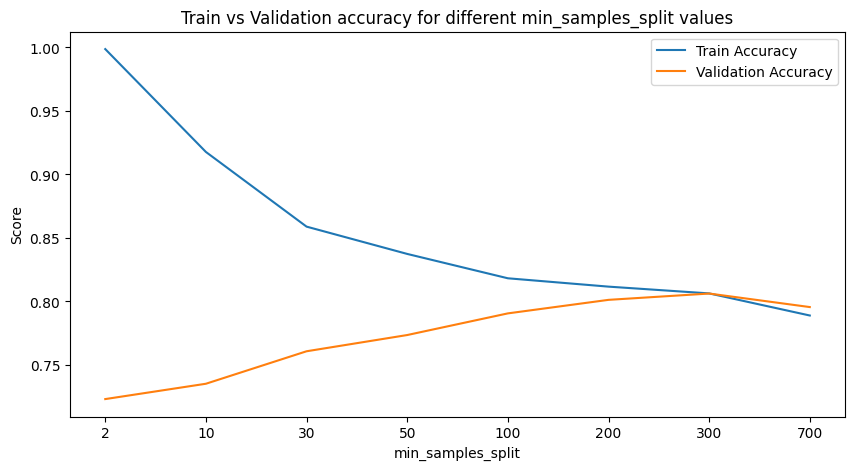

In [11]:
accuracy_scores_train = []  
accuracy_scores_val = []  

for min_samples_split in min_samples_split_list:
    model = DecisionTreeClassifier(min_samples_split=min_samples_split, random_state=42)
    model.fit(xtrain, ytrain)
    ytrain_pred = model.predict(xtrain)
    yval_pred = model.predict(xval) 
    accuracy_train = accuracy_score(ytrain, ytrain_pred)
    accuracy_val = accuracy_score(yval, yval_pred)
    accuracy_scores_train.append(accuracy_train)
    accuracy_scores_val.append(accuracy_val)
    
plt.figure(figsize=(10, 5))

plt.title('Train vs Validation accuracy for different min_samples_split values')
plt.xlabel('min_samples_split')
plt.ylabel('Score')
plt.xticks(ticks = range(len(min_samples_split_list)), labels=min_samples_split_list)
plt.plot(accuracy_scores_train)
plt.plot(accuracy_scores_val)
plt.legend(['Train Accuracy', 'Validation Accuracy'])

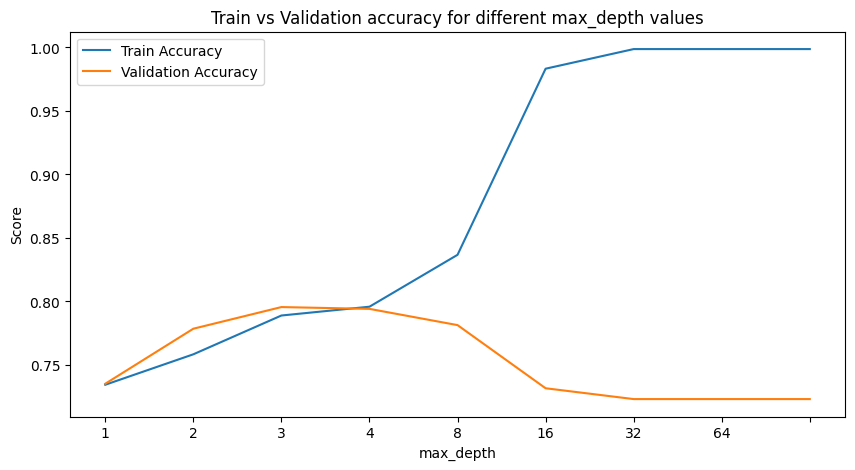

In [12]:
accuracy_scores_train = []  
accuracy_scores_val = []   
for max_depth in max_depth_list:
    
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(xtrain, ytrain)
    ytrain_pred = model.predict(xtrain)
    yval_pred = model.predict(xval)
    accuracy_train = accuracy_score(ytrain, ytrain_pred)
    accuracy_val = accuracy_score(yval, yval_pred)
    accuracy_scores_train.append(accuracy_train)
    accuracy_scores_val.append(accuracy_val)

plt.figure(figsize=(10, 5))
plt.title('Train vs Validation accuracy for different max_depth values')
plt.xlabel('max_depth')
plt.ylabel('Score')
plt.xticks(ticks = range(len(max_depth_list)), labels=max_depth_list)
plt.plot(accuracy_scores_train)
plt.plot(accuracy_scores_val)
plt.legend(['Train Accuracy', 'Validation Accuracy'])


In [13]:
df_ecnoded.Churn.sum()/len(df_ecnoded)

np.float64(0.2653698707936959)

In [14]:
(df_ecnoded['Churn'] == 1).sum()

np.int64(1869)

In [15]:
(df_ecnoded['Churn'] == 0).sum()

np.int64(5174)

In [ ]:
xtrain2, xval2, ytrain2, yval2 = train_test_split(features, target, test_size=0.4, random_state=42)
xval2, xtest2, yval2, ytest2 = train_test_split(xval2, yval2, test_size=0.5, random_state=42)

min_samples_split: 2, Train Accuracy: 0.9985798816568048, Validation Accuracy: 0.7310149041873669, Test Accuracy: 0.7210787792760823
min_samples_split: 10, Train Accuracy: 0.9145562130177515, Validation Accuracy: 0.752306600425834, Test Accuracy: 0.759403832505323
min_samples_split: 30, Train Accuracy: 0.858224852071006, Validation Accuracy: 0.7636621717530163, Test Accuracy: 0.7778566359119943
min_samples_split: 50, Train Accuracy: 0.8390532544378698, Validation Accuracy: 0.7636621717530163, Test Accuracy: 0.7821149751596878
min_samples_split: 100, Train Accuracy: 0.8220118343195266, Validation Accuracy: 0.78708303761533, Test Accuracy: 0.7885024840312278
min_samples_split: 200, Train Accuracy: 0.805207100591716, Validation Accuracy: 0.7998580553584103, Test Accuracy: 0.8055358410220014
min_samples_split: 300, Train Accuracy: 0.7940828402366864, Validation Accuracy: 0.794889992902768, Test Accuracy: 0.8055358410220014
min_samples_split: 700, Train Accuracy: 0.7869822485207101, Validat

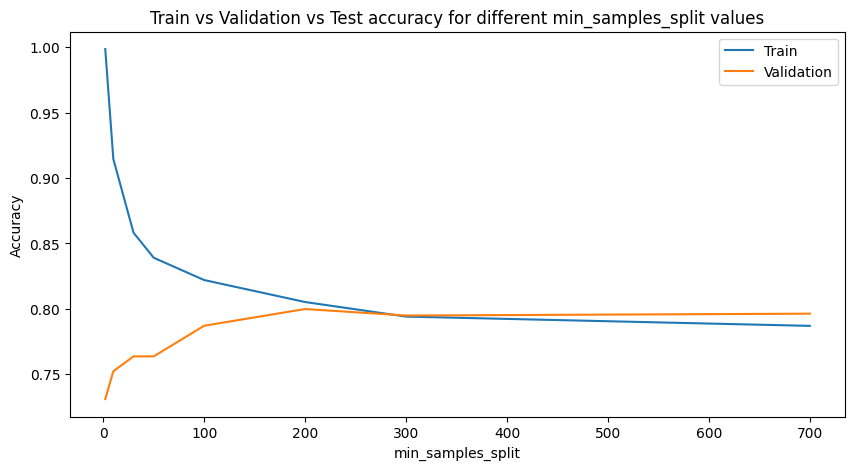

In [35]:
accuracy_scores_train = []
accuracy_scores_val = []
accuracy_scores_test = []
for min_sample in min_samples_split_list:
    model = DecisionTreeClassifier(min_samples_split=min_sample, random_state=42)
    model.fit(xtrain2, ytrain2)
    ytrain_pred = model.predict(xtrain2)
    yval_pred = model.predict(xval2) 
    ytest_pred = model.predict(xtest2)
    accuracy_train = accuracy_score(ytrain2, ytrain_pred)
    accuracy_val = accuracy_score(yval2, yval_pred)
    accuracy_test = accuracy_score(ytest2, ytest_pred)
    accuracy_scores_train.append(accuracy_train)
    accuracy_scores_val.append(accuracy_val)
    accuracy_scores_test.append(accuracy_test)
    print(f'min_samples_split: {min_sample}, Train Accuracy: {accuracy_train}, Validation Accuracy: {accuracy_val}, Test Accuracy: {accuracy_test}')

plt.figure(figsize=(10, 5))
plt.title('Train vs Validation vs Test accuracy for different min_samples_split values')
plt.xlabel('min_samples_split')
plt.ylabel('Accuracy')
plt.plot(min_samples_split_list, accuracy_scores_train, label='Train')
plt.plot(min_samples_split_list, accuracy_scores_val, label='Validation')
plt.legend()
plt.show()

Max Depth: 1, Train Score: 0.7349112426035503, CV Score: 0.7317246273953159
Max Depth: 2, Train Score: 0.7581065088757396, CV Score: 0.7686302342086586
Max Depth: 3, Train Score: 0.7869822485207101, CV Score: 0.7963094393186657
Max Depth: 4, Train Score: 0.7884023668639053, CV Score: 0.7906316536550745
Max Depth: 8, Train Score: 0.8369230769230769, CV Score: 0.7665010645848119
Max Depth: 16, Train Score: 0.9808284023668639, CV Score: 0.723207948899929
Max Depth: 32, Train Score: 0.9985798816568048, CV Score: 0.7310149041873669
Max Depth: 64, Train Score: 0.9985798816568048, CV Score: 0.7310149041873669
Max Depth: None, Train Score: 0.9985798816568048, CV Score: 0.7310149041873669


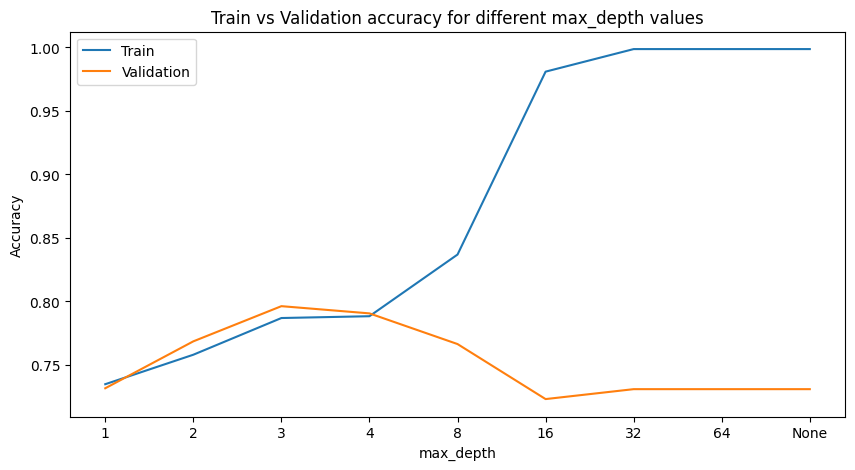

In [33]:
accuracy_scores_train = []
accuracy_scores_val = []
accuracy_scores_test = []
for max_depth in max_depth_list:
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(xtrain2, ytrain2)
    train_pred = model.predict(xtrain2)
    val_pred = model.predict(xval2)
    train_score = accuracy_score(train_pred, ytrain2)
    val_score = accuracy_score(val_pred, yval2)
    accuracy_scores_train.append(train_score)
    accuracy_scores_val.append(val_score)
    print(f'Max Depth: {max_depth}, Train Score: {train_score}, CV Score: {val_score}')

plt.figure(figsize=(10, 5))
plt.title('Train vs Validation accuracy for different max_depth values')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.plot(accuracy_scores_train, label='Train')
plt.plot(accuracy_scores_val, label='Validation')
plt.xticks(ticks=range(len(max_depth_list)), labels=[str(d) for d in max_depth_list])
plt.legend()
plt.show()

In [ ]:
# Now use both max_depth and min_samples.

accuracy_scores_train = []
accuracy_scores_val = []
accuracy_scores_test = []
model = DecisionTreeClassifier(max_depth=3, min_samples_split=200, random_state=42)
model.fit(xtrain2, ytrain2)
train_pred = model.predict(xtrain2)
val_pred = model.predict(xval2)
test_pred = model.predict(xtest2)
train_score = accuracy_score(train_pred, ytrain2)
val_score = accuracy_score(val_pred, yval2)
test_score = accuracy_score(test_pred, ytest2)
accuracy_scores_train.append(train_score)
accuracy_scores_val.append(val_score)
print(f'Train Score: {train_score}, CV Score: {val_score}, Test Score: {test_score}')


Train Score: 0.7869822485207101, CV Score: 0.7963094393186657, Test Score: 0.794180269694819


In [16]:
x_train3, x_test3, y_train3, y_test3 = train_test_split(features, target, test_size=0.2, random_state=42)

min_samples_split: 2, Train Accuracy: 0.9985800496982605, Test Accuracy: 0.723207948899929
min_samples_split: 10, Train Accuracy: 0.9176428824991125, Test Accuracy: 0.7352732434350603
min_samples_split: 30, Train Accuracy: 0.8588924387646433, Test Accuracy: 0.7608232789212207
min_samples_split: 50, Train Accuracy: 0.8374156904508342, Test Accuracy: 0.7735982966643009
min_samples_split: 100, Train Accuracy: 0.8182463613773517, Test Accuracy: 0.7906316536550745
min_samples_split: 200, Train Accuracy: 0.8116790912318069, Test Accuracy: 0.801277501774308
min_samples_split: 300, Train Accuracy: 0.806354277600284, Test Accuracy: 0.8062455642299503
min_samples_split: 700, Train Accuracy: 0.7889598864039759, Test Accuracy: 0.7955997161107168


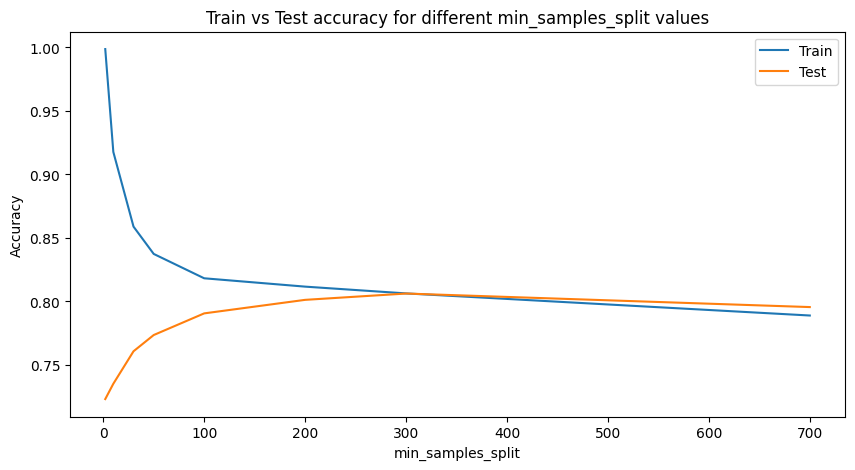

In [20]:
accuracy_scores_train = []
accuracy_scores_test = []

for min_samples_split in min_samples_split_list:
    model = DecisionTreeClassifier(min_samples_split=min_samples_split, random_state=42)
    model.fit(x_train3, y_train3)
    y_train_pred = model.predict(x_train3)
    y_test_pred = model.predict(x_test3) 
    accuracy_train = accuracy_score(y_train3, y_train_pred)
    accuracy_test = accuracy_score(y_test3, y_test_pred)
    accuracy_scores_train.append(accuracy_train)
    accuracy_scores_test.append(accuracy_test)
    print(f'min_samples_split: {min_samples_split}, Train Accuracy: {accuracy_train}, Test Accuracy: {accuracy_test}')
plt.figure(figsize=(10, 5))
plt.title('Train vs Test accuracy for different min_samples_split values')  
plt.xlabel('min_samples_split')
plt.ylabel('Accuracy')
plt.plot(min_samples_split_list, accuracy_scores_train, label='Train')
plt.plot(min_samples_split_list, accuracy_scores_test, label='Test')
plt.legend()
plt.show()

At `min_sample = 200`, a little overfitting but negligible?

max_depth: 1, Train Accuracy: 0.7344692935747249, Test Accuracy: 0.7352732434350603
max_depth: 2, Train Accuracy: 0.758430954916578, Test Accuracy: 0.7785663591199432
max_depth: 3, Train Accuracy: 0.7889598864039759, Test Accuracy: 0.7955997161107168
max_depth: 4, Train Accuracy: 0.7958821441249556, Test Accuracy: 0.794180269694819
max_depth: 8, Train Accuracy: 0.8367057152999645, Test Accuracy: 0.7814052519517388
max_depth: 16, Train Accuracy: 0.9831380901668442, Test Accuracy: 0.7317246273953159
max_depth: 32, Train Accuracy: 0.9985800496982605, Test Accuracy: 0.723207948899929
max_depth: 64, Train Accuracy: 0.9985800496982605, Test Accuracy: 0.723207948899929
max_depth: None, Train Accuracy: 0.9985800496982605, Test Accuracy: 0.723207948899929


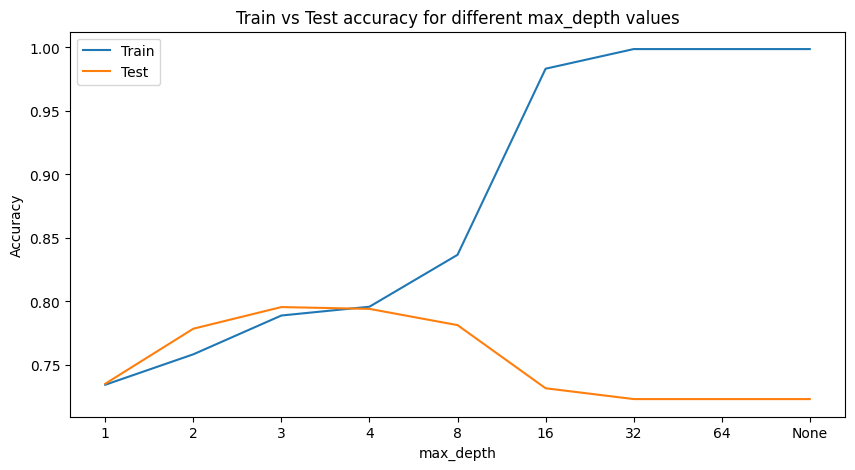

In [22]:
accuracy_scores_test = []
accuracy_scores_train = []

for max_depth in max_depth_list:
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(x_train3, y_train3)
    y_train_pred = model.predict(x_train3)
    y_test_pred = model.predict(x_test3) 
    accuracy_train = accuracy_score(y_train3, y_train_pred)
    accuracy_test = accuracy_score(y_test3, y_test_pred)
    accuracy_scores_train.append(accuracy_train)
    accuracy_scores_test.append(accuracy_test)
    print(f'max_depth: {max_depth}, Train Accuracy: {accuracy_train}, Test Accuracy: {accuracy_test}')

plt.figure(figsize=(10, 5))
plt.title('Train vs Test accuracy for different max_depth values')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.plot(accuracy_scores_train, label='Train')
plt.plot(accuracy_scores_test, label='Test')
plt.xticks(ticks=range(len(max_depth_list)), labels=[str(d) for d in max_depth_list])
plt.legend()
plt.show()

At `max_depth = 3`?

Now try all combinations of max_depth and min_samples_split and find the best combination.

min_samples_split: 2, max_depth: 1, Train Accuracy: 0.7344692935747249, Test Accuracy: 0.7352732434350603
min_samples_split: 2, max_depth: 2, Train Accuracy: 0.758430954916578, Test Accuracy: 0.7785663591199432
min_samples_split: 2, max_depth: 3, Train Accuracy: 0.7889598864039759, Test Accuracy: 0.7955997161107168
min_samples_split: 2, max_depth: 4, Train Accuracy: 0.7958821441249556, Test Accuracy: 0.794180269694819
min_samples_split: 2, max_depth: 8, Train Accuracy: 0.8367057152999645, Test Accuracy: 0.7814052519517388
min_samples_split: 2, max_depth: 16, Train Accuracy: 0.9831380901668442, Test Accuracy: 0.7317246273953159
min_samples_split: 2, max_depth: 32, Train Accuracy: 0.9985800496982605, Test Accuracy: 0.723207948899929
min_samples_split: 2, max_depth: 64, Train Accuracy: 0.9985800496982605, Test Accuracy: 0.723207948899929
min_samples_split: 2, max_depth: None, Train Accuracy: 0.9985800496982605, Test Accuracy: 0.723207948899929
min_samples_split: 10, max_depth: 1, Train Ac

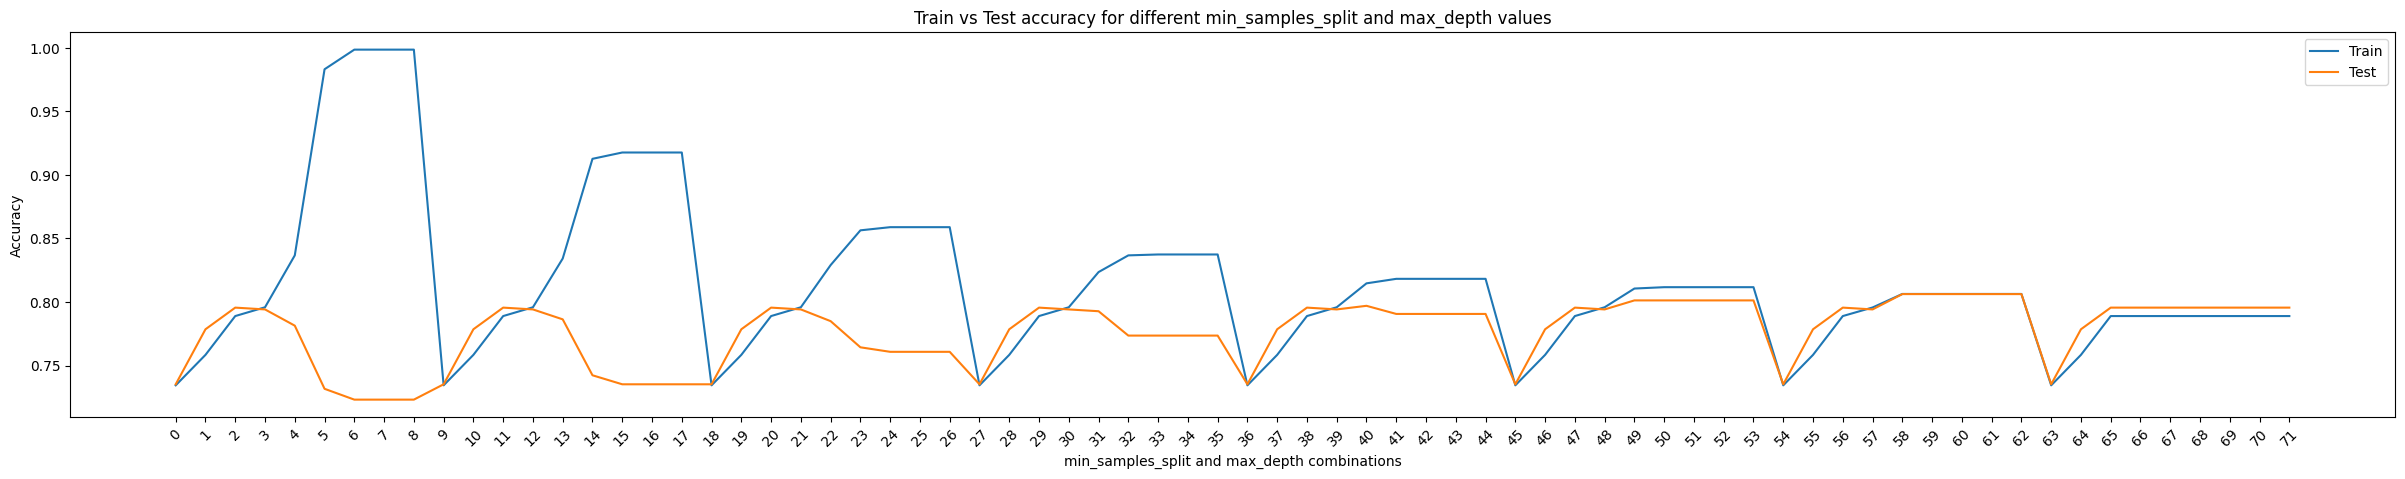

In [30]:
accuracy_scores_train = []
accuracy_scores_test = []

for min_samples_split in min_samples_split_list:
    for max_depth in max_depth_list:
        model = DecisionTreeClassifier(min_samples_split=min_samples_split, max_depth=max_depth, random_state=42)
        model.fit(x_train3, y_train3)
        y_train_pred = model.predict(x_train3)
        y_test_pred = model.predict(x_test3) 
        accuracy_train = accuracy_score(y_train3, y_train_pred)
        accuracy_test = accuracy_score(y_test3, y_test_pred)
        accuracy_scores_train.append([min_samples_split, max_depth, accuracy_train])
        accuracy_scores_test.append([min_samples_split, max_depth, accuracy_test])
        print(f'min_samples_split: {min_samples_split}, max_depth: {max_depth}, Train Accuracy: {accuracy_train}, Test Accuracy: {accuracy_test}')

plt.figure(figsize=(30, 5))
plt.title('Train vs Test accuracy for different min_samples_split and max_depth values')
plt.xlabel('min_samples_split and max_depth combinations')
plt.ylabel('Accuracy')
plt.plot([row[2] for row in accuracy_scores_train], label='Train')
plt.plot([row[2] for row in accuracy_scores_test], label='Test')
plt.xticks(ticks=range(len(accuracy_scores_train)), rotation=45)
plt.legend()
plt.show()

[[0.73527324 0.77856636 0.79559972 0.79418027 0.78140525 0.73172463
  0.72320795 0.72320795 0.72320795]
 [0.73527324 0.77856636 0.79559972 0.79418027 0.78637331 0.74237048
  0.73527324 0.73527324 0.73527324]
 [0.73527324 0.77856636 0.79559972 0.79418027 0.78495387 0.76437189
  0.76082328 0.76082328 0.76082328]
 [0.73527324 0.77856636 0.79559972 0.79418027 0.79276082 0.7735983
  0.7735983  0.7735983  0.7735983 ]
 [0.73527324 0.77856636 0.79559972 0.79418027 0.79701916 0.79063165
  0.79063165 0.79063165 0.79063165]
 [0.73527324 0.77856636 0.79559972 0.79418027 0.8012775  0.8012775
  0.8012775  0.8012775  0.8012775 ]
 [0.73527324 0.77856636 0.79559972 0.79418027 0.80624556 0.80624556
  0.80624556 0.80624556 0.80624556]
 [0.73527324 0.77856636 0.79559972 0.79559972 0.79559972 0.79559972
  0.79559972 0.79559972 0.79559972]]


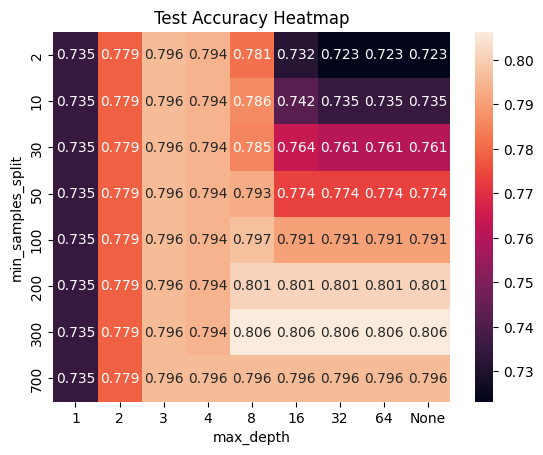

In [33]:
import numpy as np
import seaborn as sns

scores = np.array([row[2] for row in accuracy_scores_test]).reshape(len(min_samples_split_list), len(max_depth_list))
print(scores)
sns.heatmap(scores, annot=True, fmt='.3f',
              xticklabels=[str(d) for d in max_depth_list],
              yticklabels=min_samples_split_list)
plt.xlabel('max_depth')
plt.ylabel('min_samples_split')
plt.title('Test Accuracy Heatmap')
plt.show()

In [34]:
max_depth = 8
min_samples_split = 200
model = DecisionTreeClassifier(max_depth=max_depth, min_samples_split=min_samples_split, random_state=42)
model.fit(x_train3, y_train3)
y_train_pred = model.predict(x_train3)
y_test_pred = model.predict(x_test3)
train_score = accuracy_score(y_train3, y_train_pred)
test_score = accuracy_score(y_test3, y_test_pred)
print(f'Train Accuracy: {train_score}, Test Accuracy: {test_score}')

Train Accuracy: 0.8106141285055023, Test Accuracy: 0.801277501774308


A little worse than the random forest (tree ensemble)

In [43]:
### Data is a little skewed so calculating F1 Score.

f1, prec, recall = f1_score(y_train_pred, y_train3)
print(f'f1: {f1}, precesion: {prec}, recall: {recall}')

f1: 0.5894574836475568, precesion: 0.6944696282864914, recall: 0.5120320855614974


This is bad. Recall at 51% = the model misclassifies half of positive examples.

In [48]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'min_samples_split': min_samples_split_list,
    'max_depth': max_depth_list,
}

grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid=param_grid, cv=3, n_jobs=-1)
grid_search.fit(x_train3, y_train3)
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'max_depth': 8, 'min_samples_split': 200}


Different than the heatmap results. `GridSearchCV` trains on K-folds.

In [56]:
model = DecisionTreeClassifier(max_depth=8, min_samples_split=200, random_state=42)
model.fit(x_train3, y_train3)
y_pred = model.predict(x_train3)
y_test_pred = model.predict(x_test3)
train_accuracy = accuracy_score(y_train3, y_pred)
test_accuracy = accuracy_score(y_test3, y_test_pred)

print(f'Train Accuracy: {train_accuracy}, Test Accuracy: {test_accuracy}')
f1, prec, recall = f1_score(y_pred, y_train3)
print(f'f1: {f1}, precesion: {prec}, recall: {recall}')
f1, prec, recall = f1_score(y_test_pred, y_test3)
print(f'f1: {f1}, precesion: {prec}, recall: {recall}')



Train Accuracy: 0.8106141285055023, Test Accuracy: 0.801277501774308
f1: 0.5894574836475568, precesion: 0.6944696282864914, recall: 0.5120320855614974
f1: 0.5638629283489096, precesion: 0.6728624535315985, recall: 0.48525469168900803
